# Self-subtraction correction for ADI

The general idea of the self-subtraction correction is to extract the peak spectrum in an ADI cube (in the science roll), then build a model of the planet signal, subtract it from the reference roll, recompute the 3d spline for the reference roll, subtract the improved 3d spline model from the science roll, rinse and repeat.

Before you attempt to run this script, make sure that ADI has been applied once to both rolls.

This tutorial is a work in progress. Use with caution.


The following cell is mostly identical to the HIP 65426 tutorial since we also need to setup paths and other breads configurations.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from multiprocess import Pool
import subprocess
from astropy.io import fits
import matplotlib.patheffects as PathEffects

# breads jwst reduction_utils
from breads.jwst_reduction.reduction_utils import find_files_to_process
from breads.jwst_reduction.reduction_utils import run_complete_stage1_2_nirspec
from breads.jwst_reduction.reduction_utils import recenter_coordinates_per_frame_nirspec
from breads.jwst_reduction.reduction_utils import compute_normalized_stellar_spectrum
from breads.jwst_reduction.reduction_utils import compute_3dsplines
from breads.jwst_reduction.reduction_utils import cube_extraction,extract_spectrum,compute_snr_grid

# breads jwst_tools
from breads.jwst_tools.splines import plot_3dspline_residuals
from breads.jwst_tools.breadspsf import create_BreadsPSF
import breads.jwst_tools.default_nirspec as default
from scipy.interpolate import interp1d

In [2]:
# To prevent numpy paralellization when using multiprocessing. (TBC if needed)
os.environ["OPENBLAS_NUM_THREADS"] = "1"   # export OPENBLAS_NUM_THREADS=1
os.environ["MKL_NUM_THREADS"] = "1"        # export MKL_NUM_THREADS=1

# Number of threads to be used for the parallelized steps in BREADS
numthreads = 8
# Base directory where the data products will be saved
base_path = '/stow/jruffio/data/JWST/nirspec/HIP_65426/' # change me
# path to your conda environment bin directory where it can find jwst_download.py
JWSTDL_path = '~/anaconda3/envs/breads_2026/bin/' # change me
# Object name used for various labeling needs
targetname = "HIP_65426"  # change me
# Simbad object name. This is for the automated Simbad query inside BREADS to get the absolute RA/Dec of the star to define the Delta RA and delta Dec coordinates of the point cloud.
simbad_name = "HIP 65426" # change me
# JWST program number
program = '8063' # change me
uncal_path = os.path.join(base_path, f'uncal_{program}') # Path where to save the uncal files
# Dates range between which the MAST query will look for the uncal data to download
date_string = '2025-07-01 2025-07-31' # change me
# Observing number for the dataset, see the JWST APT file for the program
obsnum = "obsnum06" # # change me, e.g., "obsnum05" or "obsnum06"
# detector to process
detector = "nrs2" # change me, e.g. "nrs1" or "nrs2"
grating = "G395H"# change me, e.g. "G140H", "G395H", "G395H"
# Define utils directory (for all intermediate data products, there are lots of them)
utils_dir = os.path.join(base_path,obsnum+"_"+program, grating+"_utils")
if not os.path.exists(utils_dir):
    os.makedirs(utils_dir)
# Define output directory (for extracted spectra, SNR maps, etc.)
out_dir = os.path.join(base_path,obsnum+"_"+program, grating+"_out")
if not os.path.exists(out_dir):
    os.makedirs(out_dir)
# defines the x/y-axis sampling for computing BreadsPSF
x_vec = np.arange(-1.5,1.5, 0.02)
y_vec = np.arange(-1.5,1.5, 0.02)
# defines the x/y-axis sampling for computing cube extraction
ra_vec = np.arange(-2,2, 0.05)
dec_vec = np.arange(-2,2, 0.05)
# Using BREADS default wavelength sampling when interpolating the data on a regular wavelength grid
wv_sampling = default.wv_sampling_dict[grating][detector]

# For known planets, define their astrometry here. This is used for various tasks like masking, plotting, or initial spectral extraction.
# See http://whereistheplanet.com/
ra_planets  = {"b":418.245} # in mas
dec_planets = {"b":-694.532} # in mas
sep_planets = {"b":810.709} # in mas
pa_planets  = {"b":148.943} # in degrees from North
# make it a list of tuples
ra_dec_point_sources = [[ra_planets["b"],dec_planets["b"]],]
# Radial velocity of the central star.
star_rv = 3.1 # https://simbad.u-strasbg.fr/simbad/sim-id?Ident=HIP+65426&NbIdent=1&Radius=2&Radius.unit=arcmin&submit=submit+id

# Configure breads_data directory variables
BREADS_DATA_ENV = os.getenv('BREADS_DATA')
breadspsf_dir = os.path.join(os.environ['BREADS_DATA'], "BreadsPSF")

# initialize multiprocessing pool
mypool = Pool(processes=numthreads)

if grating == "G395H":
    filename_filter = "jw0806300"+obsnum[-1::]+"001_02101_000*_"+detector+"_uncal.fits"
    if detector == "nrs1":
        mask_charge_transfer_radius = 0.11 # in as
        IWA_cen, OWA_cen = 0.3, 1.0 # in as
        wv_min_cen, wv_max_cen = 3.0,3.8 # in microns
        clean_1f_noise,model_charge_transfer = True,True
    elif detector == "nrs2":
        mask_charge_transfer_radius = None
        IWA_cen, OWA_cen = 0.0, 1.0 # in as
        wv_min_cen, wv_max_cen = 4.4, 5.1 # in microns
        clean_1f_noise,model_charge_transfer = True,False
elif grating == "G140H":
    pass # Could be filled if G140H data is available

The self-subtraction correction is iterative. let's first define the number of iteration we want to perform. You can always increase this number later as previously computed iterations are saved and will be reused with the default settings.

We are also defining other ADI paths here to specify which rolls to use. This is a bit messy right now, hopefully this can be streamlined eventually.

In [3]:
ADI_N_iter = 4

#/stow/jruffio/data/JWST/nirspec/HIP_65426/obsnum05_8063/G395H_stage2_cleaned
cleaned_cal_files = find_files_to_process(os.path.join(base_path,obsnum+"_"+program,grating+"_stage2_cleaned"), filetype=filename_filter.replace("uncal.fits","cal.fits"))
splitbasename = os.path.basename(cleaned_cal_files[0]).split("_")
utils_dir = os.path.join(base_path,obsnum+"_"+program, grating+"_utils")
out_dir = os.path.join(base_path,obsnum+"_"+program, grating+"_out")
ADI_out_dir = os.path.join(base_path,obsnum+"_"+program, grating+"_out_ADI")
if not os.path.exists(ADI_out_dir):
    os.makedirs(ADI_out_dir)

combined_contnorm_spec_filename = os.path.join(utils_dir, splitbasename[0] + "_" + splitbasename[1]+ "_" + detector + "_starspec_contnorm_combined_1dspline.fits")
centroid_suffix = "_fitspsf_breadspsf"
pl = "b"
ra_offset = ra_planets[pl] / 1000.  # ra offset in as
dec_offset = dec_planets[pl] / 1000.  # dec offset in as
xy_coords = (ra_offset,dec_offset)
cube_mode = "ASDI"
if obsnum == "obsnum05":
    ADI_obsnum = "obsnum06"
    ADI_filename_filter = "jw08063006"+"001_02101_000*_"+detector+"_uncal.fits"
    ADI_prefix = "jw08063006001_02101_" + detector
elif obsnum == "obsnum06":
    ADI_obsnum = "obsnum05"
    ADI_filename_filter = "jw08063005"+"001_02101_000*_"+detector+"_uncal.fits"
    ADI_prefix = "jw08063005001_02101_" + detector
ADI_cleaned_cal_files = find_files_to_process(os.path.join(base_path,ADI_obsnum+"_"+program,grating+"_stage2_cleaned"), filetype=ADI_filename_filter.replace("uncal.fits","cal.fits"))
ADI_utils_dir = os.path.join(base_path, ADI_obsnum + "_" + program, grating + "_utils")
ADI_splitbasename = os.path.basename(ADI_cleaned_cal_files[0]).split("_")
ADI_combined_contnorm_spec_filename = os.path.join(ADI_utils_dir, ADI_splitbasename[0] + "_" + ADI_splitbasename[1] + "_" + detector + "_starspec_contnorm_combined_1dspline.fits")

Searching in /stow/jruffio/data/JWST/nirspec/HIP_65426/obsnum06_8063/G395H_stage2_cleaned for files matching jw08063006001_02101_000*_nrs2_cal.fits
	Found 16 input files to process
	jw08063006001_02101_00001_nrs2_cal.fits
	jw08063006001_02101_00002_nrs2_cal.fits
	jw08063006001_02101_00003_nrs2_cal.fits
	jw08063006001_02101_00004_nrs2_cal.fits
	jw08063006001_02101_00005_nrs2_cal.fits
	jw08063006001_02101_00006_nrs2_cal.fits
	jw08063006001_02101_00007_nrs2_cal.fits
	jw08063006001_02101_00008_nrs2_cal.fits
	jw08063006001_02101_00009_nrs2_cal.fits
	jw08063006001_02101_00010_nrs2_cal.fits
	jw08063006001_02101_00011_nrs2_cal.fits
	jw08063006001_02101_00012_nrs2_cal.fits
	jw08063006001_02101_00013_nrs2_cal.fits
	jw08063006001_02101_00014_nrs2_cal.fits
	jw08063006001_02101_00015_nrs2_cal.fits
	jw08063006001_02101_00016_nrs2_cal.fits
Searching in /stow/jruffio/data/JWST/nirspec/HIP_65426/obsnum05_8063/G395H_stage2_cleaned for files matching jw08063005001_02101_000*_nrs2_cal.fits
	Found 16 input

The next step is extract the initial spectrum of the planet, which will be used as our starting point.

26 48 418.245 -694.532


Text(0, 0.5, 'Flux (MJy)')

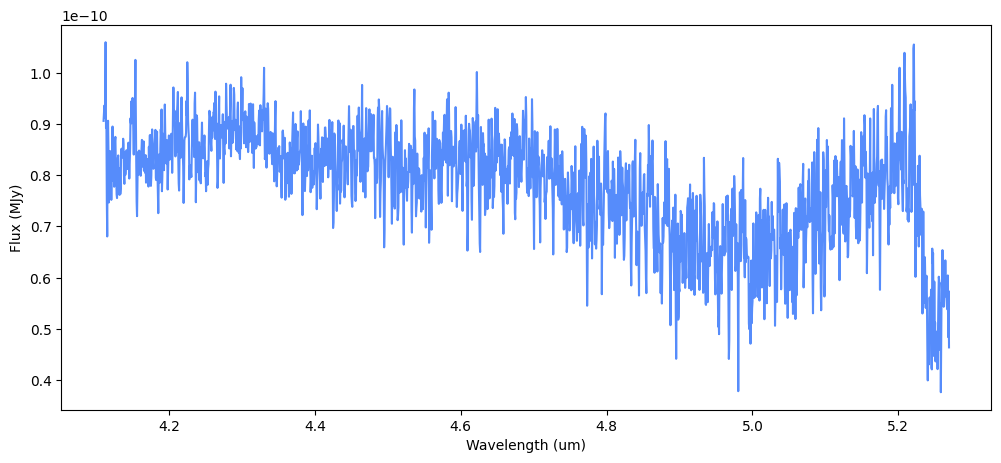

In [4]:
cube_filename = os.path.join(out_dir, splitbasename[0] + "_" + splitbasename[1] + "_" + splitbasename[3] + "_" + grating + "_" + "ADI" + "_cube.fits")
with fits.open(cube_filename) as hdulist:
    flux_cube = hdulist['FLUX'].data
    fluxerr_cube = hdulist['FLUXERR'].data
    x_grid = hdulist['X'].data
    y_grid = hdulist['Y'].data
    wv_sampling = hdulist['WAVE'].data

sum_im = np.nansum(flux_cube[100:(flux_cube.shape[0] - 100), :, :], axis=0)
# x, y = (0.4, -0.7)
x, y = ra_planets[pl] / 1000., dec_planets[pl] / 1000.
kmax, lmax = np.unravel_index(np.nanargmin(((x_grid - x) ** 2 + (y_grid - y) ** 2)), x_grid.shape)
print(kmax, lmax, ra_planets[pl], dec_planets[pl])
stamp = sum_im[kmax - 5:kmax + 5, lmax - 5:lmax + 5]
_kmax, _lmax = np.unravel_index(np.nanargmax(stamp), stamp.shape)
kmax, lmax = kmax - 5 + _kmax, lmax - 5 + _lmax
spectrum = flux_cube[:, kmax, lmax]
err = fluxerr_cube[:, kmax, lmax]
plt.figure(10,figsize=(12,5))
plt.plot(wv_sampling,spectrum,label=f"Original")
plt.xlabel("Wavelength (um)")
plt.ylabel("Flux (MJy)")

The massive next cell iterate several times performing ADI with an increasingly cleaner reference dataset; ie, with the planet being more accurately subtracted at each step.

One day this will be cleaned up.

<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:118: SyntaxWarning: invalid escape sequence '\D'
<>:119: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:118: SyntaxWarning: invalid escape sequence '\D'
<>:119: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2778236/2708008514.py:18: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("$\Delta$RA (as)", fontsize=fontsize)
/tmp/ipykernel_2778236/2708008514.py:19: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("$\Delta$Dec (as)", fontsize=fontsize)
/tmp/ipykernel_2778236/2708008514.py:118: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("$\Delta$RA (as)", fontsize=fontsize)
/tmp/ipykernel_2778236/2708008514.py:119: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("$\Delta$Dec (as)", fontsize=fontsize)
/home/jruffio/anaconda3/envs/breads_2026

10 10 418.245 -694.532


/home/jruffio/anaconda3/envs/breads_202605_p313/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


10 10 418.245 -694.532


/home/jruffio/anaconda3/envs/breads_202605_p313/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


10 10 418.245 -694.532


/home/jruffio/anaconda3/envs/breads_202605_p313/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


26 48 418.245 -694.532


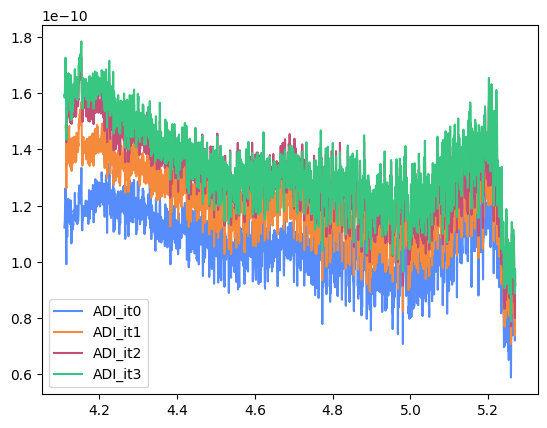

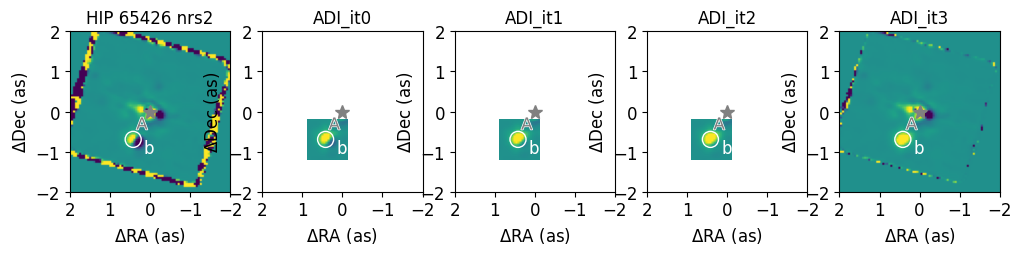

In [5]:
plt.figure(20,figsize=(12,5))
plt.subplot(1,1+ADI_N_iter,1)
fontsize = 12
x_vec, y_vec = x_grid[0, :], y_grid[:, 0]
dx, dy = x_vec[1] - x_vec[0], y_vec[1] - y_vec[0]
plt.title(simbad_name + " " + detector)
plt.imshow(np.nansum(flux_cube[100:(flux_cube.shape[0] - 100), :, :], axis=0), origin="lower",
           cmap="viridis",
           extent=[x_vec[0] - dx / 2., x_vec[-1] + dx / 2., y_vec[0] - dy / 2.,
                   y_vec[-1] + dy / 2.])
plt.clim([-1e-7, 1e-7])
plt.xlim([-2, 2])
plt.xticks([-2, -1, 0, 1, 2])
plt.ylim([-2, 2])
plt.yticks([-2, -1, 0, 1, 2])
plt.gca().invert_xaxis()
plt.gca().set_aspect('equal')
plt.xlabel("$\Delta$RA (as)", fontsize=fontsize)
plt.ylabel("$\Delta$Dec (as)", fontsize=fontsize)
plt.gca().tick_params(axis='x', labelsize=fontsize)
plt.gca().tick_params(axis='y', labelsize=fontsize)

plt.plot(0, 0, "*", color="grey", markersize=10)
txt = plt.text(0.2, -0.1, 'A', fontsize=fontsize, ha='center', va='top',
               color="grey")  # \n 1.1-2.6 Jy
txt.set_path_effects([PathEffects.withStroke(linewidth=1, foreground='w')])
# plt.plot(ra_offset, dec_offset,".",color="white",markersize=10)
for pl in ra_planets.keys():
    plt.text(ra_planets[pl] / 1000. - 0.4, dec_planets[pl] / 1000., pl, fontsize=fontsize,
             ha='center', va='top', color="white")  # \n 36-166 $\mu$Jy
    circle = plt.Circle((ra_planets[pl] / 1000., dec_planets[pl] / 1000.), 0.2,
                        facecolor='#FFFFFF00', edgecolor='white')  # ,zorder=0
    plt.gca().add_patch(circle)


for it in range(ADI_N_iter):
    ADI_it_suffix = f"ADI_it{it}"

    subtract_comp = {"centroid":[ra_planets[pl] / 1000., dec_planets[pl] / 1000.],
                     "spectrum_func":interp1d(wv_sampling,spectrum, kind = "linear", bounds_error = False, fill_value = 0),
                     "OWA":0.3}
    ADI_it_combdataobj = compute_3dsplines(ADI_cleaned_cal_files, ADI_utils_dir, simbad_name,ADI_combined_contnorm_spec_filename,
                                    coords_filename_filter = centroid_suffix+"_poly_centroid_IWA{0:.2f}_OWA{1:.2f}.txt".format(IWA_cen,OWA_cen),
                                    spline3d_suffix = "_"+ADI_it_suffix,numthreads=numthreads,centroid_per_frame=True,
                                    save_pickle=True, load_pickle=True,mask_charge_transfer_radius=None,
                                    subtract_comp=subtract_comp)

    starsub_3dspline_ADI_filename = ADI_it_combdataobj.default_filenames["compute_starsubtraction_3dspline"]
    contnorm_3dspline_ADI_filename = ADI_it_combdataobj.default_filenames["compute_starspectrum_contnorm_3dspline"]

    ##############
    ## Fewer wavelength nodes
    if it != ADI_N_iter -1:
        _ra_vec = np.arange(-0.5,0.5, 0.05)+ra_planets[pl] / 1000. # for computing cube extraction
        _dec_vec = np.arange(-0.5,0.5, 0.05)+dec_planets[pl] / 1000. # for computing cube extraction
    else:
        _ra_vec = np.arange(-2,2, 0.05)
        _dec_vec = np.arange(-2,2, 0.05)
    flux_cube4, fluxerr_cube4, x_grid, y_grid,wv_sampling = \
        cube_extraction(cleaned_cal_files, utils_dir, ADI_out_dir, combined_contnorm_spec_filename,
                        coords_filename_filter = centroid_suffix+"_poly_centroid_IWA{0:.2f}_OWA{1:.2f}.txt".format(IWA_cen,OWA_cen),
                        mode=cube_mode, suffix=ADI_it_suffix, contnorm_suffix=None,
                        ASDI_contnorm_3dspline_filename = contnorm_3dspline_ADI_filename, ASDI_starsub_3dspline_filename = starsub_3dspline_ADI_filename,
                    x_vec=_ra_vec, y_vec=_dec_vec, wv_sampling=None,
                    mask_charge_transfer_radius=None, ra_dec_point_sources=None,
                    aper_radius=0.15,
                    mppool=mypool,
                    overwrite=False,
                    targetname=simbad_name,
                    use_stpsf=False,
                    use_breadspsf=True,
                    load_pickle=False,
                    save_pickle=False,
                    ifucoords=False)

    cube_filename = os.path.join(ADI_out_dir, splitbasename[0] + "_" + splitbasename[1] + "_" + splitbasename[3] + "_" + grating + "_" + ADI_it_suffix + "_cube.fits")
    out_filename = os.path.join(ADI_out_dir, f"{targetname}_{obsnum}_{detector}_{ADI_it_suffix}_1dspectrum.fits")
    extract_spectrum(cube_filename,out_filename,xy_coords)

    with fits.open(cube_filename) as hdulist:
        flux_cube = hdulist['FLUX'].data
        fluxerr_cube = hdulist['FLUXERR'].data
        x_grid = hdulist['X'].data
        y_grid = hdulist['Y'].data
        wv_sampling = hdulist['WAVE'].data
    sum_im = np.nansum(flux_cube[100:(flux_cube.shape[0] - 100), :, :], axis=0)
    # x, y = (0.4, -0.7)
    x,y = ra_planets[pl]/1000.,dec_planets[pl]/1000.
    kmax, lmax = np.unravel_index(np.nanargmin(((x_grid - x) ** 2 + (y_grid - y) ** 2)), x_grid.shape)
    print(kmax, lmax,ra_planets[pl],dec_planets[pl])
    stamp = sum_im[kmax-5:kmax+5,lmax-5:lmax+5]
    _kmax, _lmax = np.unravel_index(np.nanargmax(stamp), stamp.shape)
    kmax, lmax = kmax-5+_kmax, lmax-5+_lmax
    spectrum = flux_cube[:, kmax, lmax]
    err = fluxerr_cube[:, kmax, lmax]

    plt.figure(10)
    plt.plot(wv_sampling,spectrum,label=f"{ADI_it_suffix}")
    plt.legend()

    plt.figure(20)
    plt.subplot(1, 1+ADI_N_iter, 2+it)
    plt.title(f"{ADI_it_suffix}")
    fontsize = 12
    x_vec, y_vec = x_grid[0, :], y_grid[:, 0]
    dx, dy = x_vec[1] - x_vec[0], y_vec[1] - y_vec[0]
    plt.imshow(np.nansum(flux_cube[100:(flux_cube.shape[0] - 100), :, :], axis=0), origin="lower",
               cmap="viridis",
               extent=[x_vec[0] - dx / 2., x_vec[-1] + dx / 2., y_vec[0] - dy / 2.,
                       y_vec[-1] + dy / 2.])
    plt.clim([-1e-7, 1e-7])
    plt.xlim([-2, 2])
    plt.xticks([-2, -1, 0, 1, 2])
    plt.ylim([-2, 2])
    plt.yticks([-2, -1, 0, 1, 2])
    plt.gca().invert_xaxis()
    plt.gca().set_aspect('equal')
    plt.xlabel("$\Delta$RA (as)", fontsize=fontsize)
    plt.ylabel("$\Delta$Dec (as)", fontsize=fontsize)
    plt.gca().tick_params(axis='x', labelsize=fontsize)
    plt.gca().tick_params(axis='y', labelsize=fontsize)

    plt.plot(0, 0, "*", color="grey", markersize=10)
    txt = plt.text(0.2, -0.1, 'A', fontsize=fontsize, ha='center', va='top',
                   color="grey")  # \n 1.1-2.6 Jy
    txt.set_path_effects([PathEffects.withStroke(linewidth=1, foreground='w')])
    # plt.plot(ra_offset, dec_offset,".",color="white",markersize=10)
    for pl in ra_planets.keys():
        plt.text(ra_planets[pl] / 1000. - 0.4, dec_planets[pl] / 1000., pl, fontsize=fontsize,
                 ha='center', va='top', color="white")  # \n 36-166 $\mu$Jy
        circle = plt.Circle((ra_planets[pl] / 1000., dec_planets[pl] / 1000.), 0.2,
                            facecolor='#FFFFFF00', edgecolor='white')  # ,zorder=0
        plt.gca().add_patch(circle)

In [ ]:
# close multiprocessing
mypool.close()
mypool.join()